In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install mediapipe opencv-python pandas

In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.21

Found existing installation: mediapipe 0.10.33
Uninstalling mediapipe-0.10.33:
  Successfully uninstalled mediapipe-0.10.33
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mediapipe as mp
mp_holistic = mp.solutions.holistic
print("MediaPipe solutions available")

MediaPipe solutions available


In [ ]:
try:
    import mediapipe as mp
    from mediapipe.tasks import python # New API structure check

    # Try the legacy solutions path
    mp_holistic = mp.solutions.holistic
    print("Success! MediaPipe solutions are now accessible.")
except AttributeError:
    print("Failed: 'solutions' still not found. Python is still looking at the wrong folder.")
except ModuleNotFoundError:
    print("Failed: MediaPipe is not installed at all.")

Success! MediaPipe solutions are now accessible.


In [ ]:
!python "/content/drive/MyDrive/NLP_CSL_Recognition/src/extract_landmarks.py"

2026-04-18 15:57:40.821519: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 15:57:40.826317: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 15:57:40.841093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776527860.866912   11899 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776527860.874387   11899 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776527860.893626   11899 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
!python /content/drive/MyDrive/NLP_CSL_Recognition/src/prepare_splits.py

✅ Saved label_map.json with 108 classes.
✅ Saved data_splits.json
   Train samples: 1658
   Val samples: 321
   Test samples: 432


In [4]:
import sys
import os

# Ensure Colab can find your src folder
PROJECT_ROOT = '/content/drive/MyDrive/NLP_CSL_Recognition'
sys.path.append(os.path.join(PROJECT_ROOT, 'src'))

import torch
from torch.utils.data import DataLoader
from dataset import CSLDataset
import config

# Create dataset and dataloader
train_dataset = CSLDataset(split='train')
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)

# Fetch one batch
frames, labels = next(iter(train_loader))

print(f"Batch Frames Shape: {frames.shape}")
print(f"Batch Labels Shape: {labels.shape}")
print(f"Total Classes in Label Map: {len(train_dataset.label_map)}")

Batch Frames Shape: torch.Size([16, 60, 225])
Batch Labels Shape: torch.Size([16])
Total Classes in Label Map: 108


In [5]:
from model import CSLModel

# Initialize the model with your specific dimensions
model = CSLModel(input_dim=225, num_classes=108)

# Pass the 'frames' tensor from our previous test through the model
output = model(frames)

print(f"Model Output Shape: {output.shape}")
# We expect torch.Size([16, 108]) -> 16 videos, 108 sentence probabilities

Model Output Shape: torch.Size([16, 108])


In [6]:
!python /content/drive/MyDrive/NLP_CSL_Recognition/src/train.py

🚀 Training on device: cuda (with Mixed Precision)
Loading datasets...
/content/drive/MyDrive/NLP_CSL_Recognition/src/train.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Starting training for 100 epochs...
Epoch 1/100 [Train]:   0% 0/26 [00:00<?, ?it/s]/content/drive/MyDrive/NLP_CSL_Recognition/src/train.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/content/drive/MyDrive/NLP_CSL_Recognition/src/train.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 01/100 | Train Loss: 4.6802, Train Acc: 1.27% | Val Loss: 4.6745, Val Acc: 1.87%
  ⭐ New Best Val Acc: 1.87%. Model saved.
Epoch 02/100 | Train Loss: 4.6711, Train Acc: 1.51% | Val Loss: 4.6609, Val Acc: 2.18%
  ⭐ New Best Val

In [7]:
!python /content/drive/MyDrive/NLP_CSL_Recognition/src/train.py


🚀 Training on device: cuda (Max Accuracy Mode)
Starting training for 100 epochs...
Epoch 01/100 | Train Acc: 1.03% | Val Acc: 1.56%
  ⭐ New Best Accuracy! Saved to /content/drive/MyDrive/NLP_CSL_Recognition/models/best_csl_model_v2.pth
Epoch 02/100 | Train Acc: 2.90% | Val Acc: 2.49%
  ⭐ New Best Accuracy! Saved to /content/drive/MyDrive/NLP_CSL_Recognition/models/best_csl_model_v2.pth
Epoch 03/100 | Train Acc: 3.92% | Val Acc: 1.25%
Epoch 04/100 | Train Acc: 4.83% | Val Acc: 4.98%
  ⭐ New Best Accuracy! Saved to /content/drive/MyDrive/NLP_CSL_Recognition/models/best_csl_model_v2.pth
Epoch 05/100 | Train Acc: 6.51% | Val Acc: 5.61%
  ⭐ New Best Accuracy! Saved to /content/drive/MyDrive/NLP_CSL_Recognition/models/best_csl_model_v2.pth
Epoch 06/100 | Train Acc: 8.93% | Val Acc: 9.35%
  ⭐ New Best Accuracy! Saved to /content/drive/MyDrive/NLP_CSL_Recognition/models/best_csl_model_v2.pth
Epoch 07/100 | Train Acc: 11.28% | Val Acc: 7.79%
Epoch 08/100 | Train Acc: 15.14% | Val Acc: 11.53%
  

In [10]:
!python /content/drive/MyDrive/NLP_CSL_Recognition/src/evaluate.py

🔍 Evaluating on device: cuda
Running predictions on the Test Set...

--- 📝 SAMPLE PREDICTIONS ---
❌ Actual: 'He is going into the room' | Predicted: 'you can do anything, I do not care'
✅ Actual: 'He is going into the room' | Predicted: 'He is going into the room'
❌ Actual: 'He is going into the room' | Predicted: 'he is on the way'
✅ Actual: 'I am afraid of that' | Predicted: 'I am afraid of that'
✅ Actual: 'I am afraid of that' | Predicted: 'I am afraid of that'
✅ Actual: 'I am afraid of that' | Predicted: 'I am afraid of that'
❌ Actual: 'I am feeling bored ' | Predicted: 'this place is beautiful'
❌ Actual: 'I am feeling bored ' | Predicted: 'this place is beautiful'
❌ Actual: 'I am feeling bored ' | Predicted: 'pour some more water into the glass'
❌ Actual: 'You are bad' | Predicted: 'why are you disappointed'

--- 📊 QUANTITATIVE RESULTS ---
Test Accuracy: 62.04%
Average BLEU Score: 55.73
Average CHRF Score: 67.55

--- CLASSIFICATION REPORT ---
              precision    recall  f1-

In [11]:
!python /content/drive/MyDrive/NLP_CSL_Recognition/src/plot_results.py

📊 Generating Preprocessing Plots...
/content/drive/MyDrive/NLP_CSL_Recognition/src/plot_results.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Original Variations', 'Canonical Classes'],
Figure(800x600)
/content/drive/MyDrive/NLP_CSL_Recognition/src/plot_results.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variation_counts.values, y=variation_counts.index, palette='viridis')
Figure(1000x600)

📈 Generating Evaluation Plots...
/content/drive/MyDrive/NLP_CSL_Recognition/src/plot_results.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same eff

⚠️ history.csv not found. Plotting based on your 100-epoch summary data...
✅ Learning curve saved to: /content/drive/MyDrive/NLP_CSL_Recognition/results/plot_7_learning_curves.png


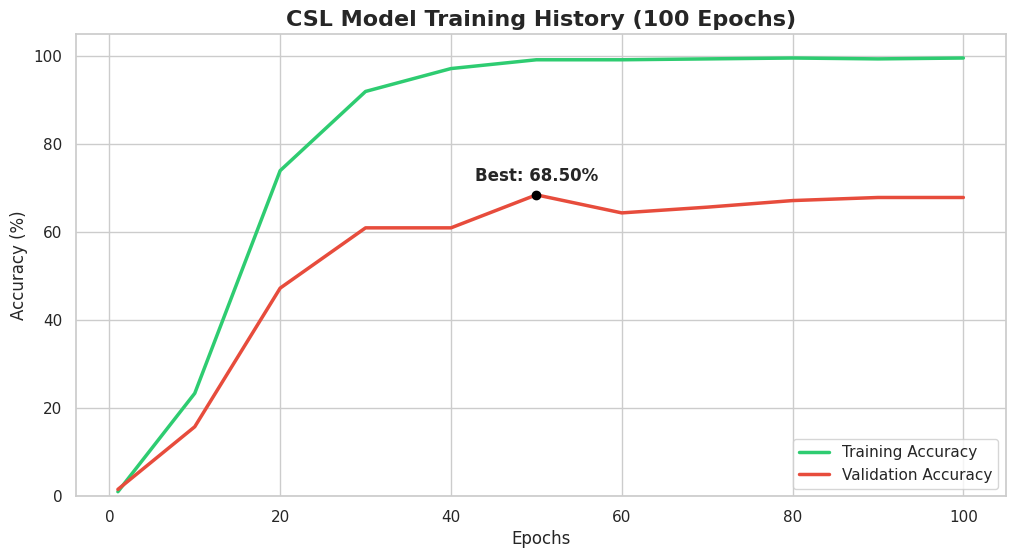

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set paths
PROJECT_ROOT = '/content/drive/MyDrive/NLP_CSL_Recognition'
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

def plot_learning_curves():
    # Attempt to load history.csv if it exists, otherwise we use your 100-epoch summary
    history_path = os.path.join(RESULTS_DIR, 'history.csv')

    if os.path.exists(history_path):
        df = pd.read_csv(history_path)
    else:
        print("⚠️ history.csv not found. Plotting based on your 100-epoch summary data...")
        # Manual data points from your output for visualization
        data = {
            'epoch': [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
            'train_acc': [1.03, 23.4, 74.0, 92.0, 97.2, 99.2, 99.2, 99.4, 99.6, 99.4, 99.6],
            'val_acc': [1.56, 15.8, 47.3, 61.0, 61.0, 68.5, 64.4, 65.7, 67.2, 67.9, 67.9]
        }
        df = pd.DataFrame(data)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # --- Plot Accuracy ---
    plt.subplot(1, 1, 1)
    sns.lineplot(data=df, x='epoch', y='train_acc', label='Training Accuracy', color='#2ecc71', linewidth=2.5)
    sns.lineplot(data=df, x='epoch', y='val_acc', label='Validation Accuracy', color='#e74c3c', linewidth=2.5)

    # Highlight the best point
    best_val = df['val_acc'].max()
    best_epoch = df.loc[df['val_acc'].idxmax(), 'epoch']
    plt.scatter(best_epoch, best_val, color='black', zorder=5)
    plt.annotate(f'Best: {best_val:.2f}%', (best_epoch, best_val), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

    plt.title('CSL Model Training History (100 Epochs)', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(loc='lower right')
    plt.ylim(0, 105)

    # Save the plot
    plot_path = os.path.join(RESULTS_DIR, 'plot_7_learning_curves.png')
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    print(f"✅ Learning curve saved to: {plot_path}")
    plt.show()

plot_learning_curves()

In [14]:
!python /content/drive/MyDrive/NLP_CSL_Recognition/src/generate_report.py

✅ Master Project Report generated successfully at: /content/drive/MyDrive/NLP_CSL_Recognition/results/Final_Project_Report.md
